In [1]:
import pandas as pd
train_path = r"D:\Universities Proj\Airline Passenger Satisfaction\data\raw\train.csv"
test_path = r"D:\Universities Proj\Airline Passenger Satisfaction\data\raw\test.csv"
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)
print(f"Train: {df_train.shape}")
print(f"Test: {df_test.shape}")
print(df_train.columns.tolist())

Train: (103904, 25)
Test: (25976, 25)
['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']


In [2]:
print(df_train.info())
print(df_train['satisfaction'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [3]:
df_train = df_train.dropna()
df_test = df_test.dropna()

print(f"Train: {df_train.shape}")
print(f"Test: {df_test.shape}")

Train: (103594, 25)
Test: (25893, 25)


In [4]:
df_train = df_train.drop(columns=['Unnamed: 0', 'id'])
df_test = df_test.drop(columns=['Unnamed: 0', 'id'])

categorical_cols = df_train.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('satisfaction')

for col in categorical_cols:
    print(f"{col}: {df_train[col].unique()}")

Gender: ['Male' 'Female']
Customer Type: ['Loyal Customer' 'disloyal Customer']
Type of Travel: ['Personal Travel' 'Business travel']
Class: ['Eco Plus' 'Business' 'Eco']


In [5]:
df_train['Gender'] = df_train['Gender'].map({'Male': 1, 'Female': 0})
df_test['Gender'] = df_test['Gender'].map({'Male': 1, 'Female': 0})

df_train['Customer Type'] = df_train['Customer Type'].map({'Loyal Customer': 1, 'disloyal Customer': 0})
df_test['Customer Type'] = df_test['Customer Type'].map({'Loyal Customer': 1, 'disloyal Customer': 0})

df_train['Type of Travel'] = df_train['Type of Travel'].map({'Business travel': 1, 'Personal Travel': 0})
df_test['Type of Travel'] = df_test['Type of Travel'].map({'Business travel': 1, 'Personal Travel': 0})

df_train['satisfaction'] = df_train['satisfaction'].map({'satisfied': 1, 'neutral or dissatisfied': 0})
df_test['satisfaction'] = df_test['satisfaction'].map({'satisfied': 1, 'neutral or dissatisfied': 0})

df_train = pd.get_dummies(df_train, columns=['Class'], drop_first=True)
df_test = pd.get_dummies(df_test, columns=['Class'], drop_first=True)

print(df_train.shape)
print(df_train.dtypes)

(103594, 24)
Gender                                 int64
Customer Type                          int64
Age                                    int64
Type of Travel                         int64
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
satisfaction                           int

In [6]:
df_train['Arrival Delay in Minutes'] = df_train['Arrival Delay in Minutes'].astype(int)
df_test['Arrival Delay in Minutes'] = df_test['Arrival Delay in Minutes'].astype(int)

bool_cols = df_train.select_dtypes(include='bool').columns.tolist()
df_train[bool_cols] = df_train[bool_cols].astype(int)
df_test[bool_cols] = df_test[bool_cols].astype(int)

print(df_train.dtypes)

Gender                               int64
Customer Type                        int64
Age                                  int64
Type of Travel                       int64
Flight Distance                      int64
Inflight wifi service                int64
Departure/Arrival time convenient    int64
Ease of Online booking               int64
Gate location                        int64
Food and drink                       int64
Online boarding                      int64
Seat comfort                         int64
Inflight entertainment               int64
On-board service                     int64
Leg room service                     int64
Baggage handling                     int64
Checkin service                      int64
Inflight service                     int64
Cleanliness                          int64
Departure Delay in Minutes           int64
Arrival Delay in Minutes             int32
satisfaction                         int64
Class_Eco                            int32
Class_Eco P

In [7]:
from sklearn.preprocessing import StandardScaler

X_train = df_train.drop(columns=['satisfaction'])
y_train = df_train['satisfaction']

X_test = df_test.drop(columns=['satisfaction'])
y_test = df_test['satisfaction']

scaler = StandardScaler()
scale_cols = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (103594, 23)
X_test: (25893, 23)
y_train: (103594,)
y_test: (25893,)


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name}:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred))


Logistic Regression:
Accuracy: 0.87
              precision    recall  f1-score   support

           0       0.87      0.90      0.89     14528
           1       0.87      0.83      0.85     11365

    accuracy                           0.87     25893
   macro avg       0.87      0.87      0.87     25893
weighted avg       0.87      0.87      0.87     25893


Random Forest:
Accuracy: 0.96
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14528
           1       0.97      0.94      0.96     11365

    accuracy                           0.96     25893
   macro avg       0.96      0.96      0.96     25893
weighted avg       0.96      0.96      0.96     25893


Gradient Boosting:
Accuracy: 0.94
              precision    recall  f1-score   support

           0       0.94      0.96      0.95     14528
           1       0.95      0.92      0.93     11365

    accuracy                           0.94     25893
   macro avg       0.94  

In [9]:
rf_model = models['Random Forest']

importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print(importances)

Online boarding                      0.181216
Inflight wifi service                0.143408
Type of Travel                       0.102166
Class_Eco                            0.075875
Inflight entertainment               0.066462
Flight Distance                      0.038184
Ease of Online booking               0.037932
Seat comfort                         0.037571
Leg room service                     0.037444
Customer Type                        0.035036
On-board service                     0.033843
Age                                  0.032869
Baggage handling                     0.025036
Cleanliness                          0.024871
Inflight service                     0.024146
Checkin service                      0.023561
Departure/Arrival time convenient    0.016450
Gate location                        0.016090
Arrival Delay in Minutes             0.012521
Food and drink                       0.011523
Departure Delay in Minutes           0.011337
Class_Eco Plus                    

In [10]:
from sklearn.metrics import accuracy_score

selected_features = importances[importances >= 0.01].index.tolist()
print(f"features selected: {len(selected_features)}")
print(selected_features)

X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

rf_model_sel = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_sel.fit(X_train_sel, y_train)
y_pred_sel = rf_model_sel.predict(X_test_sel)

print(f"\nAccuracy with all features: 0.96")
print(f"Accuracy with selected features: {accuracy_score(y_test, y_pred_sel):.2f}")

features selected: 21
['Online boarding', 'Inflight wifi service', 'Type of Travel', 'Class_Eco', 'Inflight entertainment', 'Flight Distance', 'Ease of Online booking', 'Seat comfort', 'Leg room service', 'Customer Type', 'On-board service', 'Age', 'Baggage handling', 'Cleanliness', 'Inflight service', 'Checkin service', 'Departure/Arrival time convenient', 'Gate location', 'Arrival Delay in Minutes', 'Food and drink', 'Departure Delay in Minutes']

Accuracy with all features: 0.96
Accuracy with selected features: 0.96


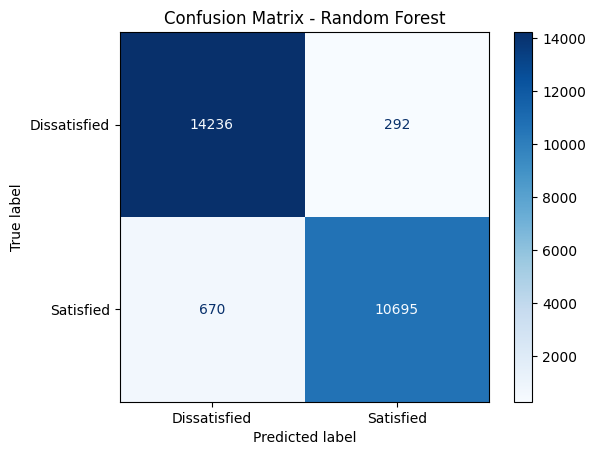

[[14236   292]
 [  670 10695]]


In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_sel)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dissatisfied', 'Satisfied'])

disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.savefig(r"D:\Universities Proj\Airline Passenger Satisfaction\data\process\confusion_matrix.png")
plt.show()

print(cm)

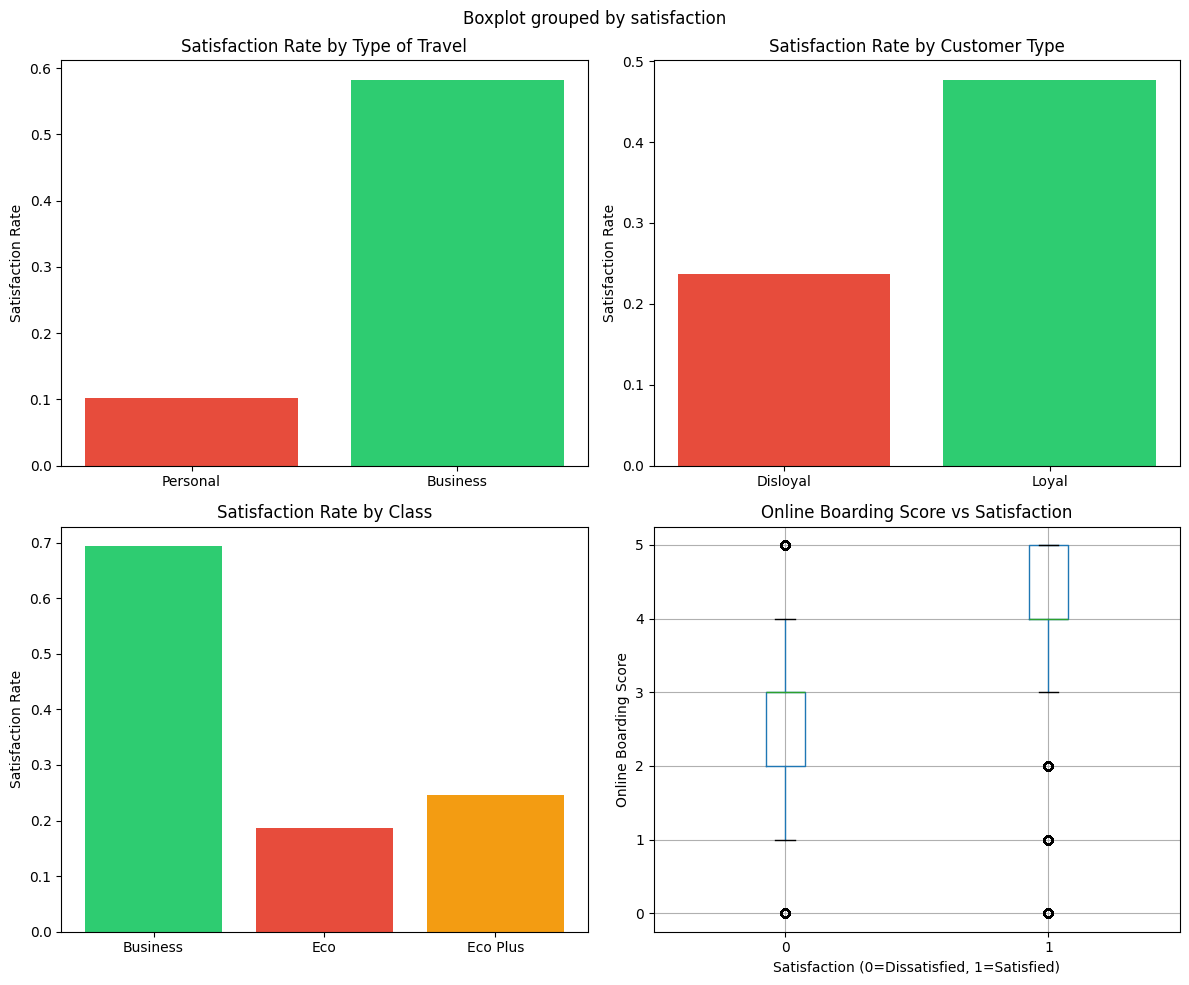

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Business Insights - Airline Passenger Satisfaction', fontsize=16)

# 1. satisfaction rate by type of travel
travel_sat = df_train.groupby('Type of Travel')['satisfaction'].mean()
axes[0, 0].bar(['Personal', 'Business'], travel_sat.values, color=['#e74c3c', '#2ecc71'])
axes[0, 0].set_title('Satisfaction Rate by Type of Travel')
axes[0, 0].set_ylabel('Satisfaction Rate')

# 2. satisfaction rate by customer type
customer_sat = df_train.groupby('Customer Type')['satisfaction'].mean()
axes[0, 1].bar(['Disloyal', 'Loyal'], customer_sat.values, color=['#e74c3c', '#2ecc71'])
axes[0, 1].set_title('Satisfaction Rate by Customer Type')
axes[0, 1].set_ylabel('Satisfaction Rate')

# 3. satisfaction rate by class
df_train['Class'] = df_train.apply(
    lambda x: 'Eco Plus' if x['Class_Eco Plus'] == 1 else ('Eco' if x['Class_Eco'] == 1 else 'Business'), axis=1
)
class_sat = df_train.groupby('Class')['satisfaction'].mean()
axes[1, 0].bar(class_sat.index, class_sat.values, color=['#2ecc71', '#e74c3c', '#f39c12'])
axes[1, 0].set_title('Satisfaction Rate by Class')
axes[1, 0].set_ylabel('Satisfaction Rate')

# 4. online boarding vs satisfaction
df_train.boxplot(column='Online boarding', by='satisfaction', ax=axes[1, 1])
axes[1, 1].set_title('Online Boarding Score vs Satisfaction')
axes[1, 1].set_xlabel('Satisfaction (0=Dissatisfied, 1=Satisfied)')
axes[1, 1].set_ylabel('Online Boarding Score')

plt.tight_layout()
plt.savefig(r"D:\Universities Proj\Airline Passenger Satisfaction\data\process\business_insights.png")
plt.show()